# BigDataAnalyticsPipeline — Layer 4: Analytics

Visualizes results stored in PostgreSQL after the full pipeline runs.

**Pipeline flow:**
```
Kaggle CSV + Generated 500k rows
  → Layer 1: Python Ingestion
  → Layer 2: PySpark Processing
  → Layer 3: PostgreSQL Storage
  → Layer 4: This Notebook ✅
```

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

# Load .env from project root
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), ".env"))
load_dotenv(os.path.join(os.getcwd(), ".env"))  # fallback if running from project root

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded.")

Libraries loaded.


## 1. Connect to PostgreSQL

In [5]:
def get_connection():
    return psycopg2.connect(
        host=os.getenv("DB_HOST", "localhost"),
        port=int(os.getenv("DB_PORT", 5432)),
        dbname=os.getenv("DB_NAME", "bigdata_pipeline"),
        user=os.getenv("DB_USER", "postgres"),
        password=os.getenv("DB_PASSWORD"),
    )

conn = get_connection()
print("Connected to PostgreSQL:", os.getenv("DB_NAME"))

Connected to PostgreSQL: bigdata_pipeline


## 2. Load Tables from DB

In [6]:
df_revenue   = pd.read_sql("SELECT * FROM revenue_per_day ORDER BY purchase_date", conn)
df_products  = pd.read_sql("SELECT * FROM top_products ORDER BY revenue DESC", conn)
df_customers = pd.read_sql("SELECT * FROM customer_segmentation", conn)

conn.close()

print(f"revenue_per_day:      {len(df_revenue):,} rows")
print(f"top_products:         {len(df_products):,} rows")
print(f"customer_segmentation:{len(df_customers):,} rows")

C:\Users\Sonic\AppData\Local\Temp\ipykernel_8700\3083999941.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue   = pd.read_sql("SELECT * FROM revenue_per_day ORDER BY purchase_date", conn)
C:\Users\Sonic\AppData\Local\Temp\ipykernel_8700\3083999941.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products  = pd.read_sql("SELECT * FROM top_products ORDER BY revenue DESC", conn)
C:\Users\Sonic\AppData\Local\Temp\ipykernel_8700\3083999941.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.r

revenue_per_day:      85 rows
top_products:         4 rows
customer_segmentation:62,822 rows


In [7]:
df_revenue["purchase_date"] = pd.to_datetime(df_revenue["purchase_date"])
df_revenue.head()

,purchase_date,revenue,transactions,avg_order_value
0,2026-01-30,1409.58,1,1409.58
1,2026-02-01,2395.89,2,1197.95
2,2026-02-07,580.06,1,580.06
3,2026-02-08,2833.28,3,944.43
4,2026-02-09,2338.44,2,1169.22


In [8]:
df_products

,product_category,revenue,units,orders
0,Smart Bundle,1.405967e+08,1880810,133410
1,Essentials,1.222700e+08,1534777,164190
2,Basics,9.155522e+07,908710,164207
3,Premium Bundle,4.603122e+07,764219,38543


In [9]:
df_customers.head()

,customer_id,lifetime_spend,avg_rating,total_items,membership_type,city,segment
0,19256,19441.55,3.99,235,Silver,San Francisco,High Value
1,45902,19311.05,4.00,201,Silver,San Francisco,High Value
2,60662,19205.52,4.08,222,Silver,San Francisco,High Value
3,56074,18772.43,3.90,255,Silver,San Francisco,High Value
4,30431,18540.94,4.09,223,Silver,San Francisco,High Value


## 3. Revenue Per Day — Line Chart

KeyError: 'total_revenue'

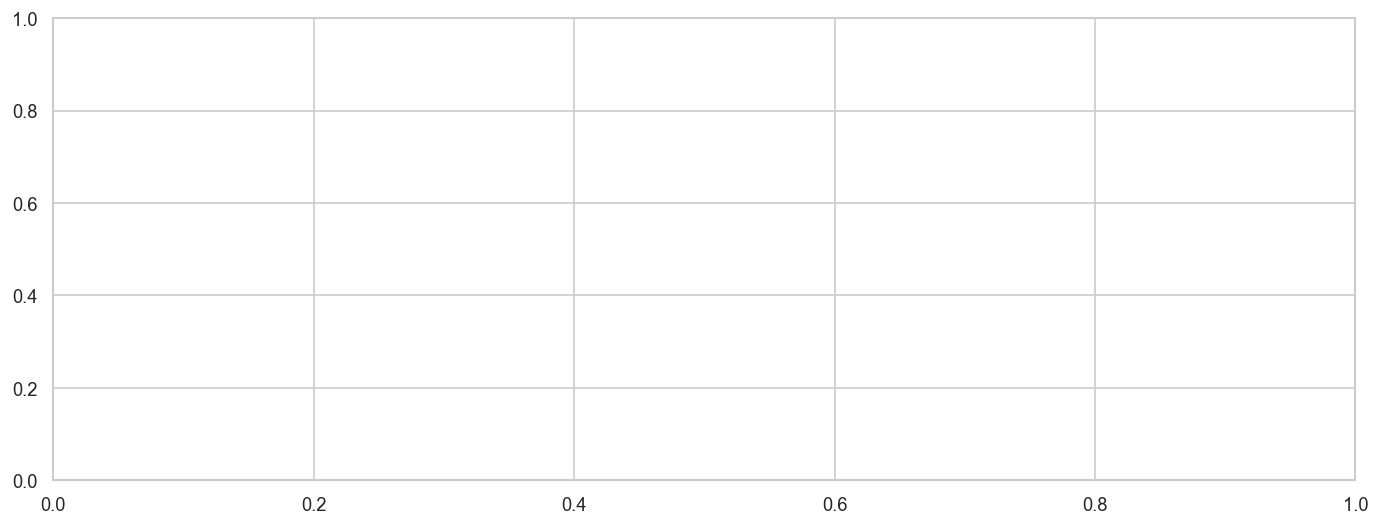

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_revenue["purchase_date"],
    df_revenue["revenue"],
    color="steelblue",
    linewidth=1.4,
    label="Daily Revenue",
)

# Rolling 7-day average
rolling = df_revenue["revenue"].rolling(7, center=True).mean()
ax.plot(
    df_revenue["purchase_date"],
    rolling,
    color="tomato",
    linewidth=2.2,
    linestyle="--",
    label="7-day Rolling Avg",
)

ax.set_title("Daily Revenue (from 500k synthetic orders)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Total Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("revenue_per_day.png", bbox_inches="tight")
plt.show()
print("Saved: revenue_per_day.png")

## 4. Top Products by Revenue — Bar Chart

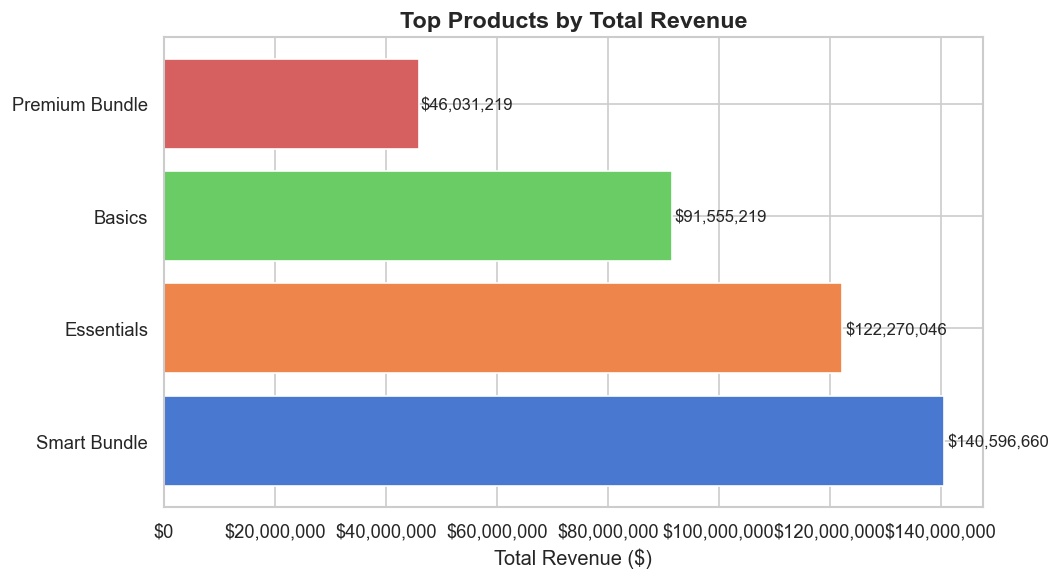

Saved: top_products.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = sns.color_palette("muted", len(df_products))
bars = ax.barh(
    df_products["product_category"],
    df_products["revenue"],
    color=colors,
    edgecolor="white",
)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * 1.005,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        fontsize=10,
    )

ax.set_title("Top Products by Total Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("top_products.png", bbox_inches="tight")
plt.show()
print("Saved: top_products.png")

## 5. Customer Segmentation

C:\Users\Sonic\AppData\Local\Temp\ipykernel_8700\4275081578.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


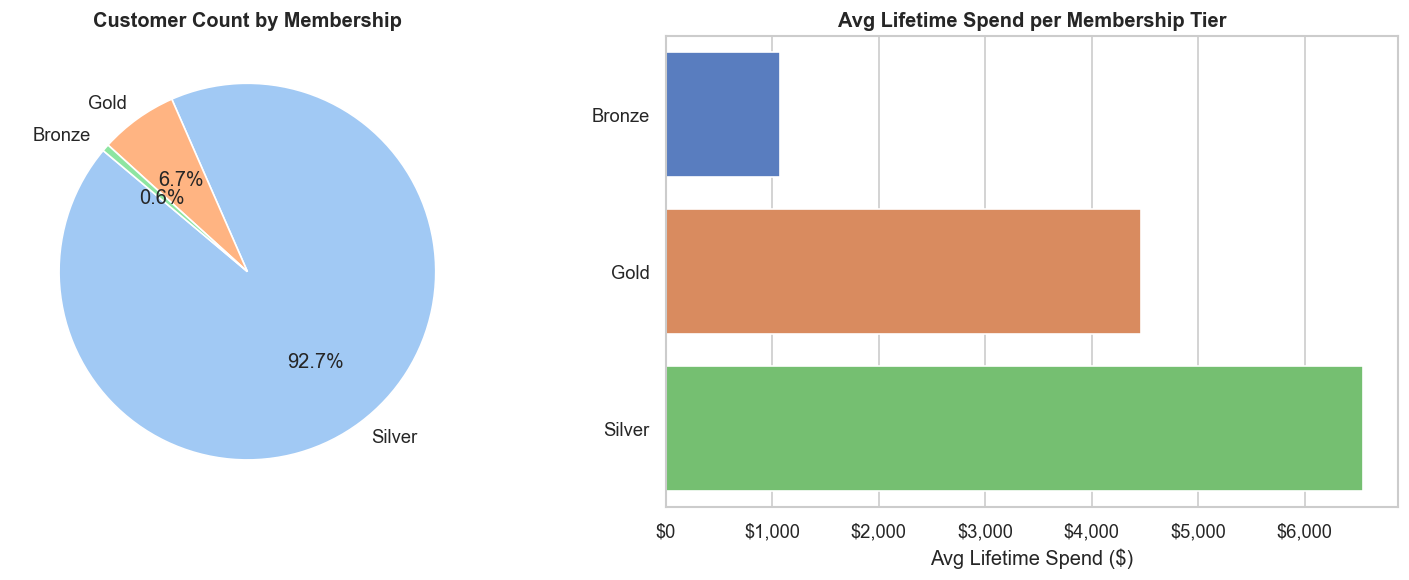

Saved: customer_segmentation.png


In [12]:
# Segment by membership type
seg_membership = (
    df_customers.groupby("membership_type")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "count"})
    .sort_values("count", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(
    seg_membership["count"],
    labels=seg_membership["membership_type"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
)
axes[0].set_title("Customer Count by Membership", fontsize=12, fontweight="bold")

# Average spend per membership
seg_spend = (
    df_customers.groupby("membership_type")["lifetime_spend"]
    .mean()
    .reset_index()
    .sort_values("lifetime_spend", ascending=True)
)
sns.barplot(
    data=seg_spend,
    y="membership_type",
    x="lifetime_spend",
    palette="muted",
    ax=axes[1],
)
axes[1].set_title("Avg Lifetime Spend per Membership Tier", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Avg Lifetime Spend ($)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("customer_segmentation.png", bbox_inches="tight")
plt.show()
print("Saved: customer_segmentation.png")

## 6. Satisfaction Score Distribution

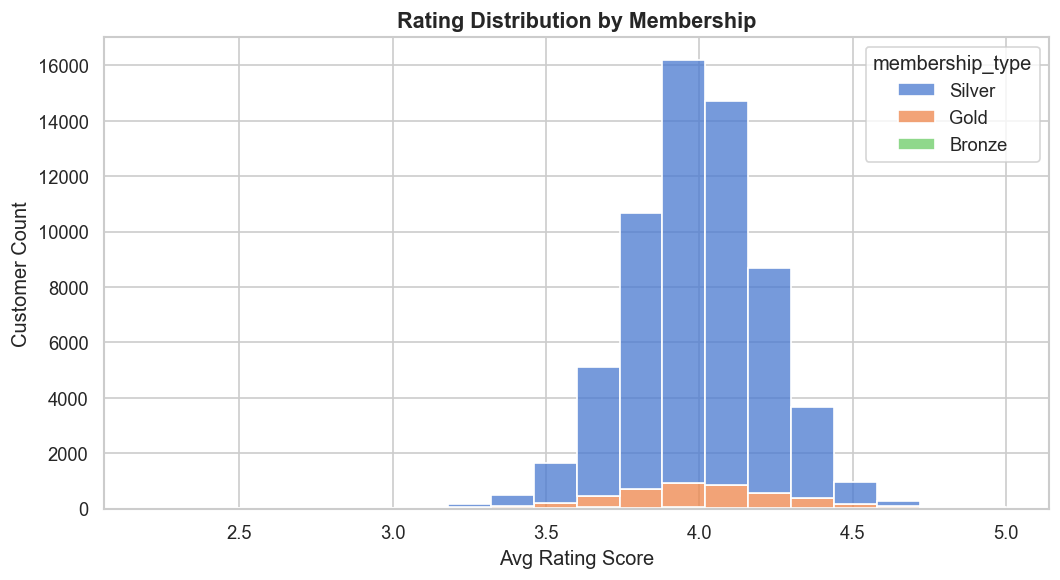

Saved: rating_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df_customers,
    x="avg_rating",
    bins=20,
    hue="membership_type",
    multiple="stack",
    palette="muted",
    ax=ax,
)

ax.set_title("Rating Distribution by Membership", fontsize=13, fontweight="bold")
ax.set_xlabel("Avg Rating Score")
ax.set_ylabel("Customer Count")
plt.tight_layout()
plt.savefig("rating_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: rating_distribution.png")

## Summary

| Chart | File |
|-------|------|
| Daily Revenue + 7-day Rolling Avg | `revenue_per_day.png` |
| Top Products by Revenue | `top_products.png` |
| Customer Segmentation (count + avg spend) | `customer_segmentation.png` |
| Satisfaction Distribution | `satisfaction_distribution.png` |